In [1]:
"""This project is a simple example of stock price prediction (using the S&P 500 index) with the NBeats model from PyTorch Forecasting."""

import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TimeSeriesDataSet, NBeats
from pytorch_forecasting.metrics import QuantileLoss, MAE, SMAPE
import warnings

warnings.filterwarnings("ignore")


# load the data
sp500: pd.DataFrame= pd.read_csv('sp500.csv', index_col='Date', 
                       skiprows=range(2), parse_dates=True)
sp500.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
sp500.index = pd.to_datetime(sp500.index)
sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6358 entries, 2000-01-03 to 2025-04-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6358 non-null   float64
 1   High    6358 non-null   float64
 2   Low     6358 non-null   float64
 3   Open    6358 non-null   float64
 4   Volume  6358 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 298.0 KB


In [2]:
sp500.tail(5)

,Close,High,Low,Open,Volume
Date,,,,,
2025-04-07,5062.250000,5246.569824,4835.040039,4953.790039,8691980000
2025-04-08,4982.770020,5267.470215,4910.419922,5193.569824,7408140000
2025-04-09,5456.899902,5481.339844,4948.430176,4965.279785,9489600000
2025-04-10,5268.049805,5353.149902,5115.270020,5353.149902,6677140000
2025-04-11,5363.359863,5381.459961,5220.770020,5255.560059,5602550000


In [3]:
# Add required features for PyTorch Forecasting
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add required features for PyTorch Forecasting."""

    df['time_idx'] = np.arange(len(df))
    df['dayofweek'] = df.index.day_name().astype('category')
    df['month'] = df.index.month_name().astype('category')
    df['year'] = df.index.year.astype('object').astype('category')
    df['Group_id'] = 'GSPC'
    return df

sp500: pd.DataFrame = add_features(sp500)
print(sp500.tail(5))

                  Close         High          Low         Open      Volume  \
Date                                                                         
2025-04-07  5062.250000  5246.569824  4835.040039  4953.790039  8691980000   
2025-04-08  4982.770020  5267.470215  4910.419922  5193.569824  7408140000   
2025-04-09  5456.899902  5481.339844  4948.430176  4965.279785  9489600000   
2025-04-10  5268.049805  5353.149902  5115.270020  5353.149902  6677140000   
2025-04-11  5363.359863  5381.459961  5220.770020  5255.560059  5602550000   

            time_idx  dayofweek  month  year Group_id  
Date                                                   
2025-04-07      6353     Monday  April  2025     GSPC  
2025-04-08      6354    Tuesday  April  2025     GSPC  
2025-04-09      6355  Wednesday  April  2025     GSPC  
2025-04-10      6356   Thursday  April  2025     GSPC  
2025-04-11      6357     Friday  April  2025     GSPC  


In [4]:
from pytorch_forecasting.data import GroupNormalizer

# Step 3, create TimeSeriesDataSet and DataLoader
max_encoder_length = 50
max_prediction_length = 20
training_cutoff = sp500['time_idx'].max() - max_prediction_length

context_length = max_encoder_length
prediction_length = max_prediction_length

training = TimeSeriesDataSet(
    sp500[sp500["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="Close",
    group_ids=["Group_id"],
    min_encoder_length=context_length,
    max_encoder_length=context_length,
    min_prediction_length=prediction_length,
    max_prediction_length=prediction_length,
    time_varying_unknown_reals=["Close"],  # nbeats only accepts a single variable as input, 
                                           # which should be the target and is part of time_varying_unknown_reals
    target_normalizer=GroupNormalizer(
        groups=["Group_id"], 
        transformation="softplus"  # use softplus and normalize by group
    ), 
    add_relative_time_idx=False, # for nbests, it must be False
)

validation = TimeSeriesDataSet.from_dataset(
    training, sp500, predict=True, stop_randomization=True, min_prediction_idx=training_cutoff + 1
)

batch_size = 32
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size)

In [5]:
# Step 4, create the baseline model and calculate the baseline model error
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
mae = MAE()(baseline_predictions.output, baseline_predictions.y)
smape = SMAPE()(baseline_predictions.output, baseline_predictions.y)
print(f"Baseline MAE: {mae:.2f}, SMAPE: {smape * 100:.2f}%")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Baseline MAE: 176.75, SMAPE: 3.25%


In [6]:
# create the N-Beats model
pl.seed_everything(17)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="gpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, lr_logger],  
    enable_checkpointing=True,
    limit_train_batches=0.5,
    logger=logger
)


net = NBeats.from_dataset(
    training,
    learning_rate=1e-5,
    stack_types=("trend", "seasonality", "generic"),  # types of stacks, Options: "trend", "seasonality", "generic"
    num_blocks=[4, 2, 2],  # number of blocks for each stack (as a list matching stack_types length)
    num_block_layers=[2, 2, 2],  # number of layers in each block
    expansion_coefficient_lengths=[4, 8, 32],
    widths=[512, 128, 64],  # widths of the stacks (as a list matching stack_types length)
    log_interval=10,
    log_val_interval=1,
    dropout=0.3,
    backcast_loss_ratio=0.2,
    loss=SMAPE(),
    optimizer="adamw",
    weight_decay=1e-2,
)

Seed set to 17
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [7]:
# train the model
trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type       | Params | Mode 
-------------------------------------------------------
0 | loss            | SMAPE      | 0      | train
1 | logging_metrics | ModuleList | 0      | train
2 | net_blocks      | ModuleList | 1.2 M  | train
-------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.968     Total estimated model params size (MB)
86        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [8]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = NBeats.load_from_checkpoint(best_model_path)

predictions = best_model.predict(val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="gpu"))
mae = MAE()(predictions.output, predictions.y)
smape = SMAPE()(predictions.output, predictions.y)
print(f"MAE: {mae:.2f}, SMAPE: {smape * 100:.2f}%")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE: 175.68, SMAPE: 3.23%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


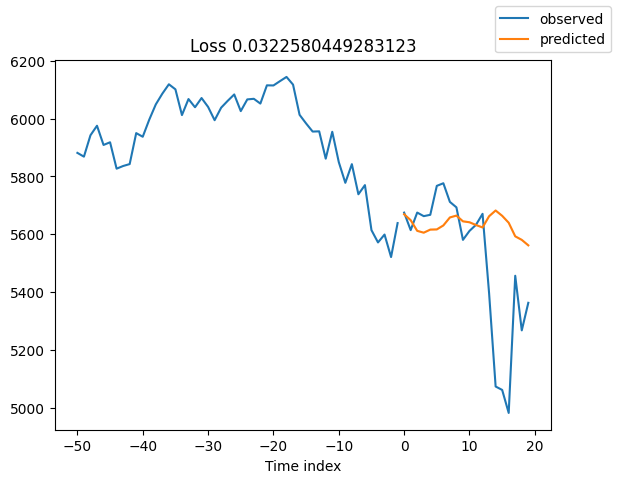

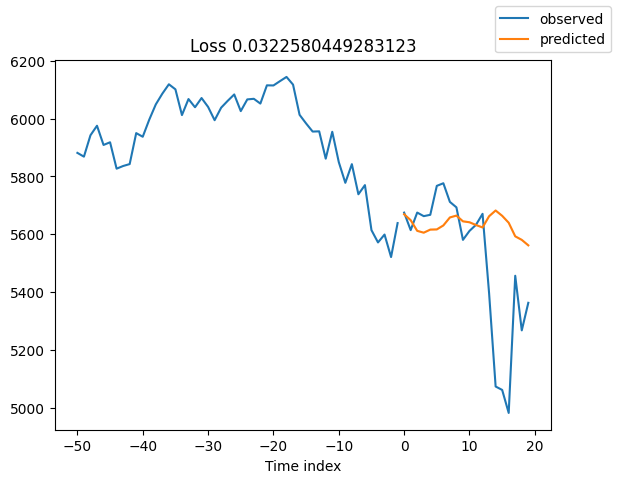

In [9]:
raw_predictions = best_model.predict(val_dataloader, mode="raw", return_x=True)
best_model.plot_prediction(
    raw_predictions.x,
    raw_predictions.output,
    idx=0,
    add_loss_to_title=True
)


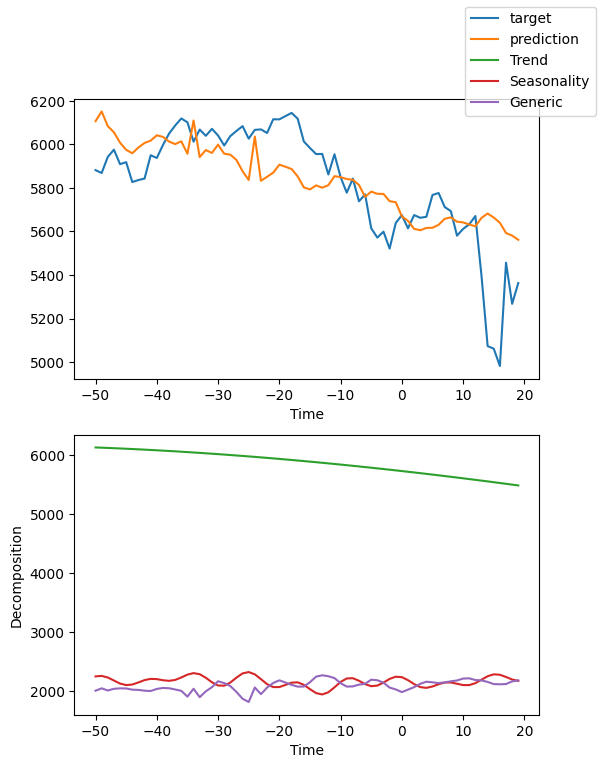

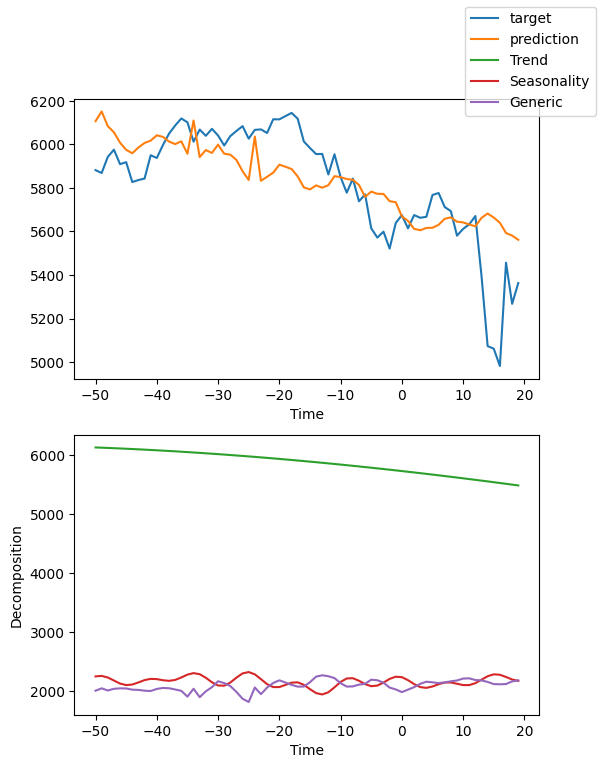

In [10]:
# interpret the model
best_model.plot_interpretation(
    raw_predictions.x,
    raw_predictions.output,
    idx=0
)